In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as f
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation


pd.set_option('display.max_rows', None)

In [2]:
spark = SparkSession.builder.getOrCreate()
train = spark.read.csv('/kaggle/input/competitions/playground-series-s6e3/train.csv', header=True, inferSchema=True)
test = spark.read.csv('/kaggle/input/competitions/playground-series-s6e3/test.csv', header=True, inferSchema=True)
submission_file = spark.read.csv('/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv',
                                 header=True, inferSchema=True)
print('Train data:')
display(train.show(1, vertical=True))
print('\n')
print('=*'*40)
print('\n Test data:')
display(test.show(1, vertical=True))

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/31 01:26:41 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Train data:
-RECORD 0------------------------
 id               | 0            
 gender           | Male         
 SeniorCitizen    | 0            
 Partner          | Yes          
 Dependents       | Yes          
 tenure           | 29           
 PhoneService     | Yes          
 MultipleLines    | No           
 InternetService  | DSL          
 OnlineSecurity   | Yes          
 OnlineBackup     | No           
 DeviceProtection | Yes          
 TechSupport      | Yes          
 StreamingTV      | No           
 StreamingMovies  | No           
 Contract         | One year     
 PaperlessBilling | Yes          
 PaymentMethod    | Mailed check 
 MonthlyCharges   | 60.1         
 TotalCharges     | 1653.85      
 Churn            | No           
only showing top 1 row


None



=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*

 Test data:
-RECORD 0----------------------------
 id               | 594194           
 gender           | Female           
 SeniorCitizen    | 0                
 Partner          | Yes              
 Dependents       | No               
 tenure           | 72               
 PhoneService     | Yes              
 MultipleLines    | Yes              
 InternetService  | Fiber optic      
 OnlineSecurity   | Yes              
 OnlineBackup     | Yes              
 DeviceProtection | Yes              
 TechSupport      | Yes              
 StreamingTV      | Yes              
 StreamingMovies  | Yes              
 Contract         | Two year         
 PaperlessBilling | Yes              
 PaymentMethod    | Electronic check 
 MonthlyCharges   | 115.55           
 TotalCharges     | 8061.5           
only showing top 1 row


None

In [3]:
# Dropping unncessary column
train, test =[i.drop('id')for i in [train, test]]
train.show(1, vertical=True)

-RECORD 0------------------------
 gender           | Male         
 SeniorCitizen    | 0            
 Partner          | Yes          
 Dependents       | Yes          
 tenure           | 29           
 PhoneService     | Yes          
 MultipleLines    | No           
 InternetService  | DSL          
 OnlineSecurity   | Yes          
 OnlineBackup     | No           
 DeviceProtection | Yes          
 TechSupport      | Yes          
 StreamingTV      | No           
 StreamingMovies  | No           
 Contract         | One year     
 PaperlessBilling | Yes          
 PaymentMethod    | Mailed check 
 MonthlyCharges   | 60.1         
 TotalCharges     | 1653.85      
 Churn            | No           
only showing top 1 row


In [4]:
test.show(1, vertical=True)

-RECORD 0----------------------------
 gender           | Female           
 SeniorCitizen    | 0                
 Partner          | Yes              
 Dependents       | No               
 tenure           | 72               
 PhoneService     | Yes              
 MultipleLines    | Yes              
 InternetService  | Fiber optic      
 OnlineSecurity   | Yes              
 OnlineBackup     | Yes              
 DeviceProtection | Yes              
 TechSupport      | Yes              
 StreamingTV      | Yes              
 StreamingMovies  | Yes              
 Contract         | Two year         
 PaperlessBilling | Yes              
 PaymentMethod    | Electronic check 
 MonthlyCharges   | 115.55           
 TotalCharges     | 8061.5           
only showing top 1 row


In [5]:
train.printSchema()

root
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: double (nullable = true)
 |-- Churn: string (nullable = true)



In [6]:
train.describe().show(vertical=True)

26/03/31 01:27:00 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


-RECORD 0--------------------------------
 summary          | count                
 gender           | 594194               
 SeniorCitizen    | 594194               
 Partner          | 594194               
 Dependents       | 594194               
 tenure           | 594194               
 PhoneService     | 594194               
 MultipleLines    | 594194               
 InternetService  | 594194               
 OnlineSecurity   | 594194               
 OnlineBackup     | 594194               
 DeviceProtection | 594194               
 TechSupport      | 594194               
 StreamingTV      | 594194               
 StreamingMovies  | 594194               
 Contract         | 594194               
 PaperlessBilling | 594194               
 PaymentMethod    | 594194               
 MonthlyCharges   | 594194               
 TotalCharges     | 594194               
 Churn            | 594194               
-RECORD 1--------------------------------
 summary          | mean          

In [7]:
categorical_columns = [col for col, dtype in train.dtypes if dtype=='string']
categorical_columns

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [8]:
for _ in categorical_columns:
    train.select(_).distinct().show()

+------+
|gender|
+------+
|Female|
|  Male|
+------+



+-------+
|Partner|
+-------+
|     No|
|    Yes|
+-------+



+----------+
|Dependents|
+----------+
|        No|
|       Yes|
+----------+



+------------+
|PhoneService|
+------------+
|          No|
|         Yes|
+------------+



+----------------+
|   MultipleLines|
+----------------+
|No phone service|
|              No|
|             Yes|
+----------------+



...

+-------------------+
|        StreamingTV|
+-------------------+
|                 No|
|                Yes|
|No internet service|
+-------------------+



+-------------------+
|    StreamingMovies|
+-------------------+
|                 No|
|                Yes|
|No internet service|
+-------------------+



+--------------+
|      Contract|
+--------------+
|Month-to-month|
|      One year|
|      Two year|
+--------------+

+----------------+
|PaperlessBilling|
+----------------+
|              No|
|             Yes|
+----------------+



+--------------------+
|       PaymentMethod|
+--------------------+
|Credit card (auto...|
|        Mailed check|
|Bank transfer (au...|
|    Electronic check|
+--------------------+



+-----+
|Churn|
+-----+
|   No|
|  Yes|
+-----+



In [9]:
# Removing duplicates
train = train.drop_duplicates()
print(f'New shape is {train.count(), len(train.columns)}')

New shape is (594194, 20)


In [10]:
# Checking for nulls
train.select([f.count(f.when(f.col(c).isNull(), c)).alias(c) for c in train.columns]).show(vertical=True)

-RECORD 0---------------
 gender           | 0   
 SeniorCitizen    | 0   
 Partner          | 0   
 Dependents       | 0   
 tenure           | 0   
 PhoneService     | 0   
 MultipleLines    | 0   
 InternetService  | 0   
 OnlineSecurity   | 0   
 OnlineBackup     | 0   
 DeviceProtection | 0   
 TechSupport      | 0   
 StreamingTV      | 0   
 StreamingMovies  | 0   
 Contract         | 0   
 PaperlessBilling | 0   
 PaymentMethod    | 0   
 MonthlyCharges   | 0   
 TotalCharges     | 0   
 Churn            | 0   



In [11]:
numeric_columns = [column for column in train.columns if column not in categorical_columns]
numeric_columns

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [12]:
pd_df = train.toPandas()
pd_df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,No,No,9,Yes,Yes,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,61.25,605.85,No
1,Female,0,No,No,1,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,25.25,25.25,No
2,Male,1,Yes,No,57,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),96.70,5580.80,No


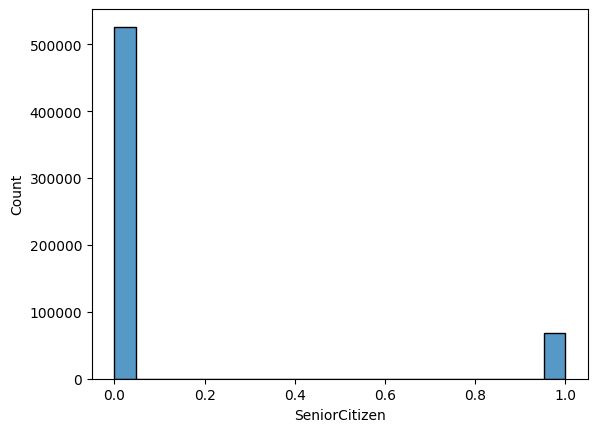

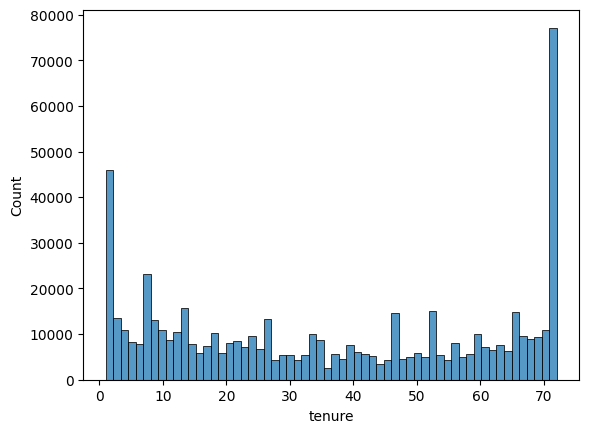

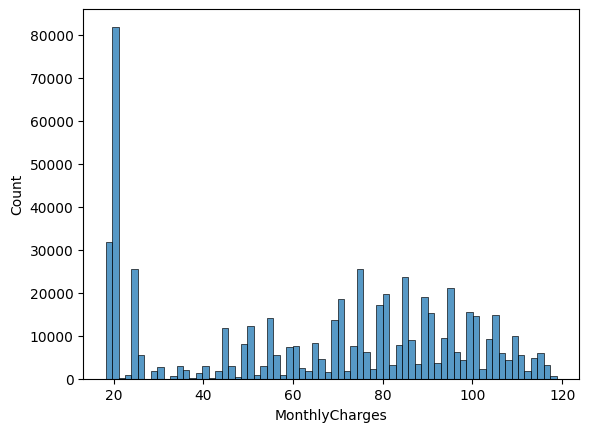

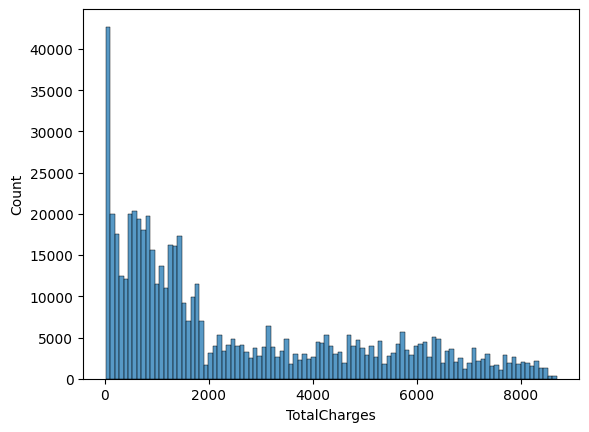

In [13]:
# Checking distribution of columns
for col in numeric_columns:
    plt.figure()
    sns.histplot(pd_df[col])

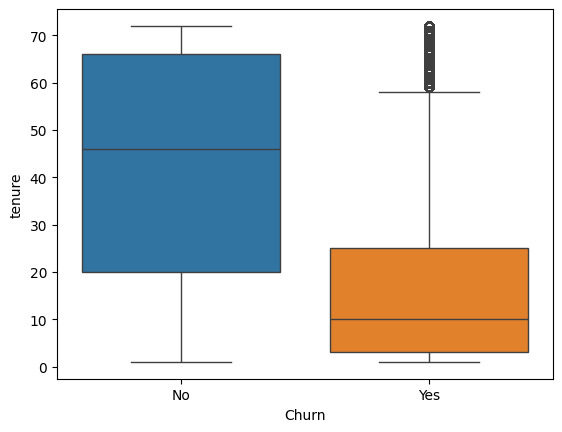

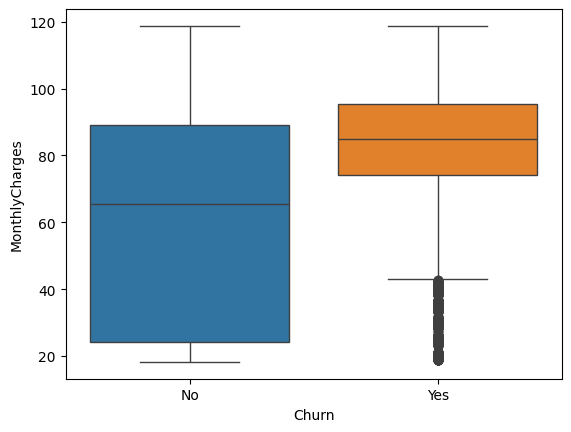

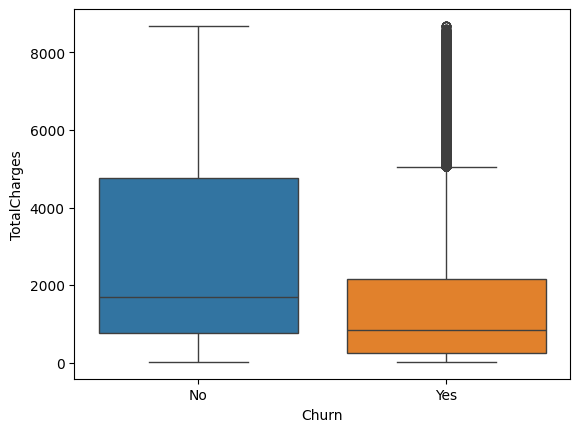

In [14]:
# Checking distribution of columns
for col in numeric_columns:
    if col != 'SeniorCitizen':
        plt.figure()
        sns.boxplot(data=pd_df, x='Churn', y=col, hue='Churn')

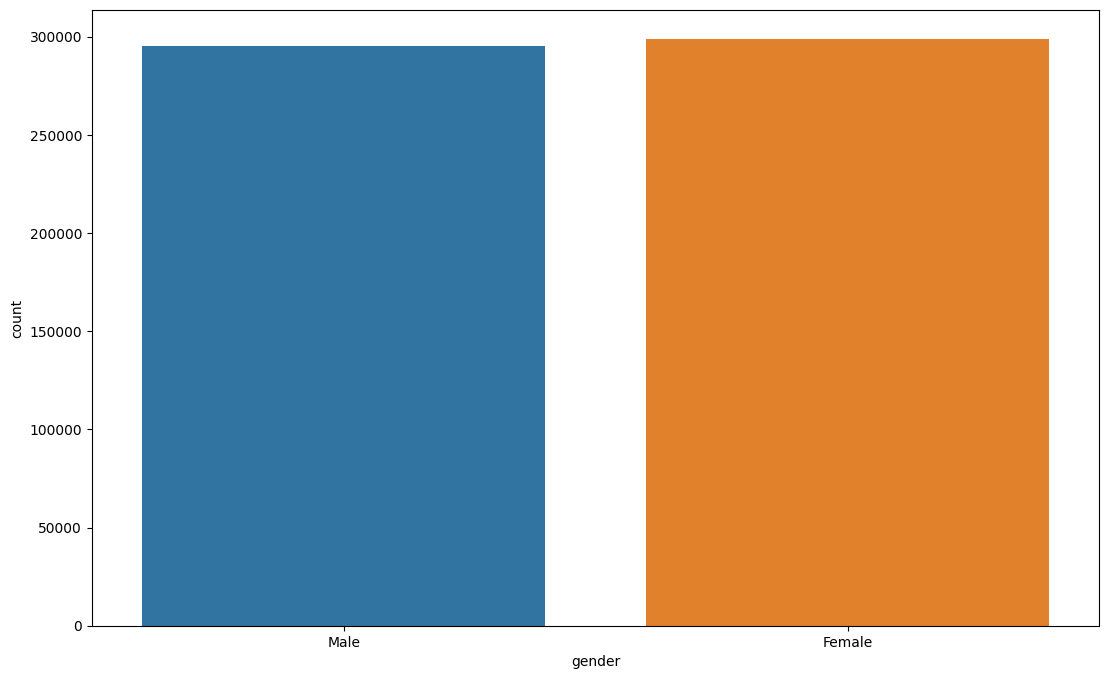

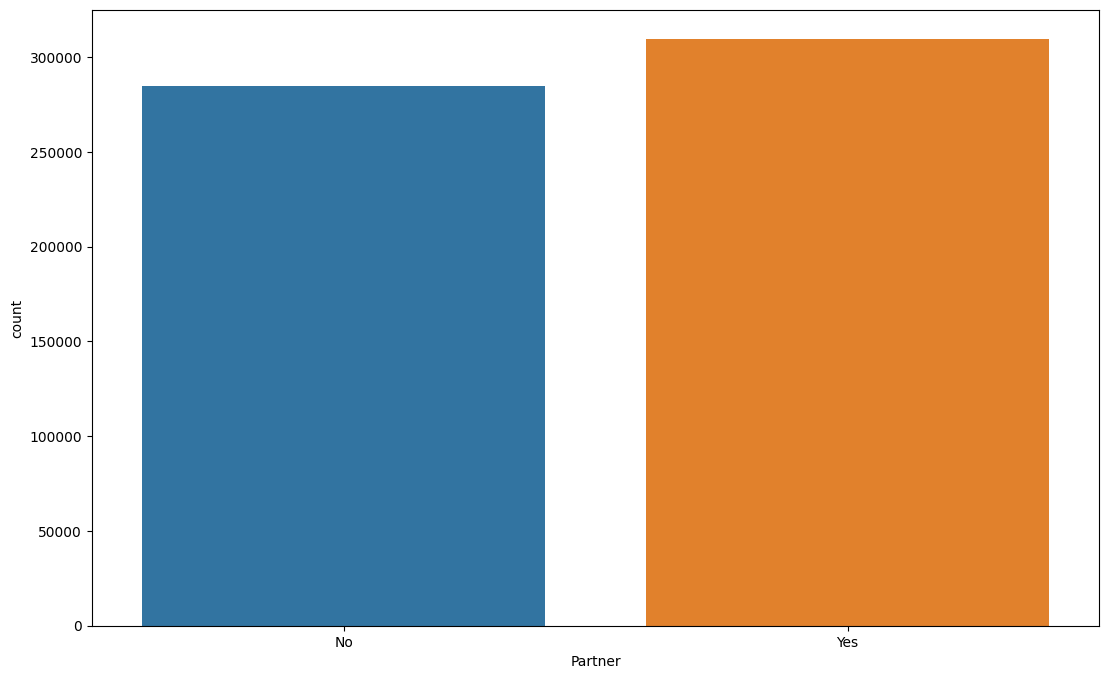

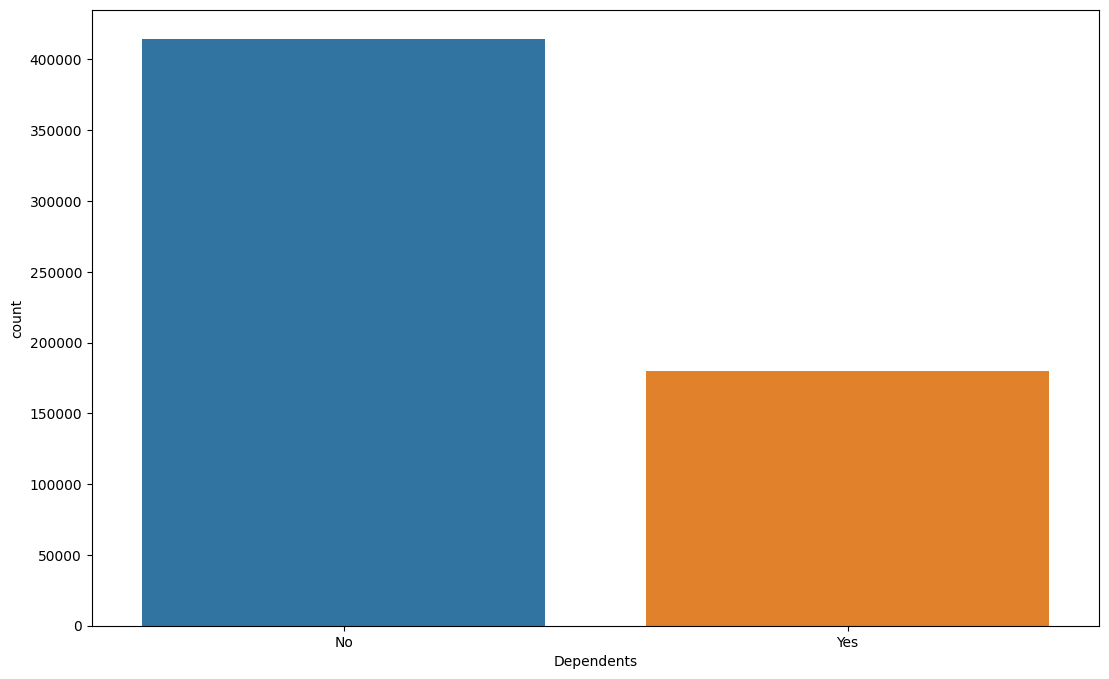

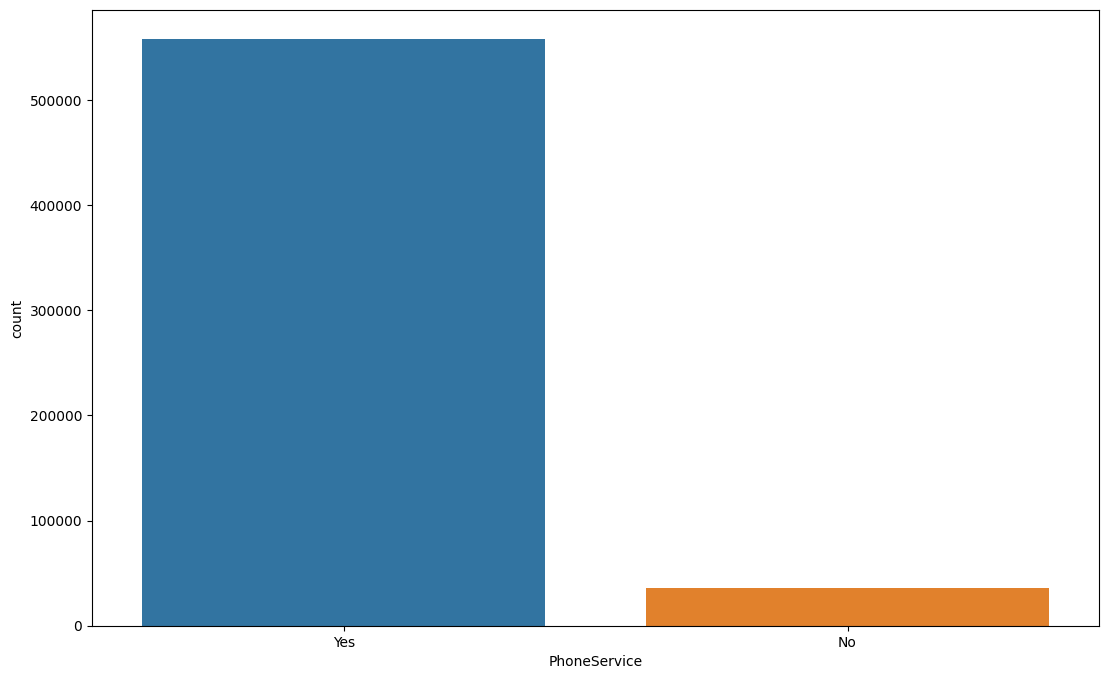

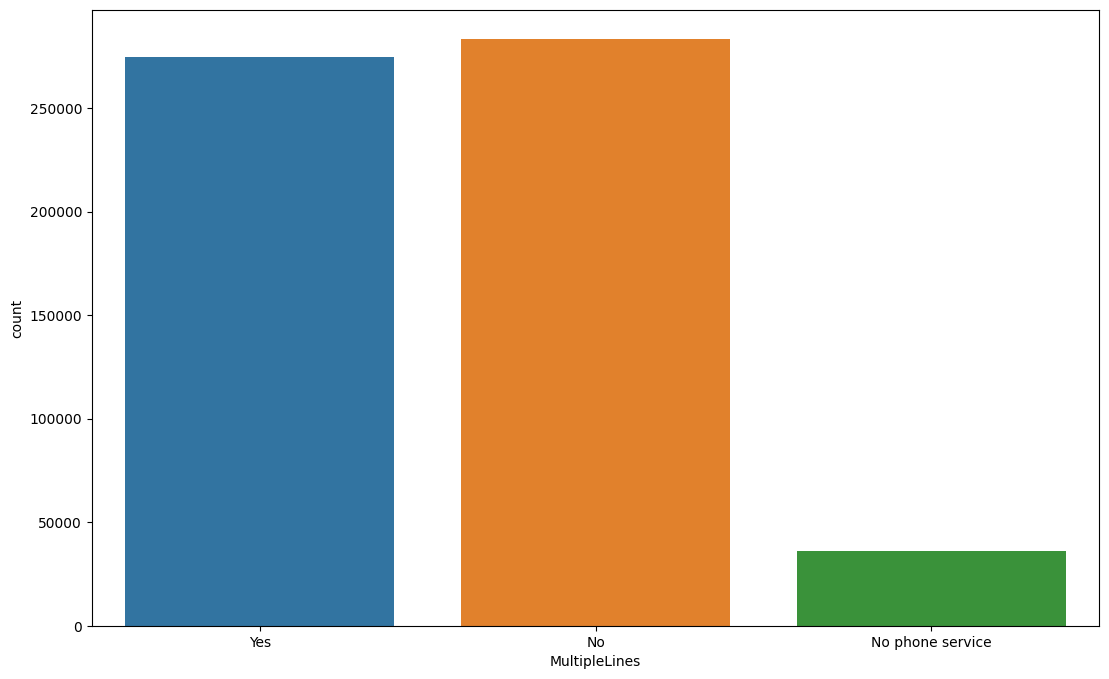

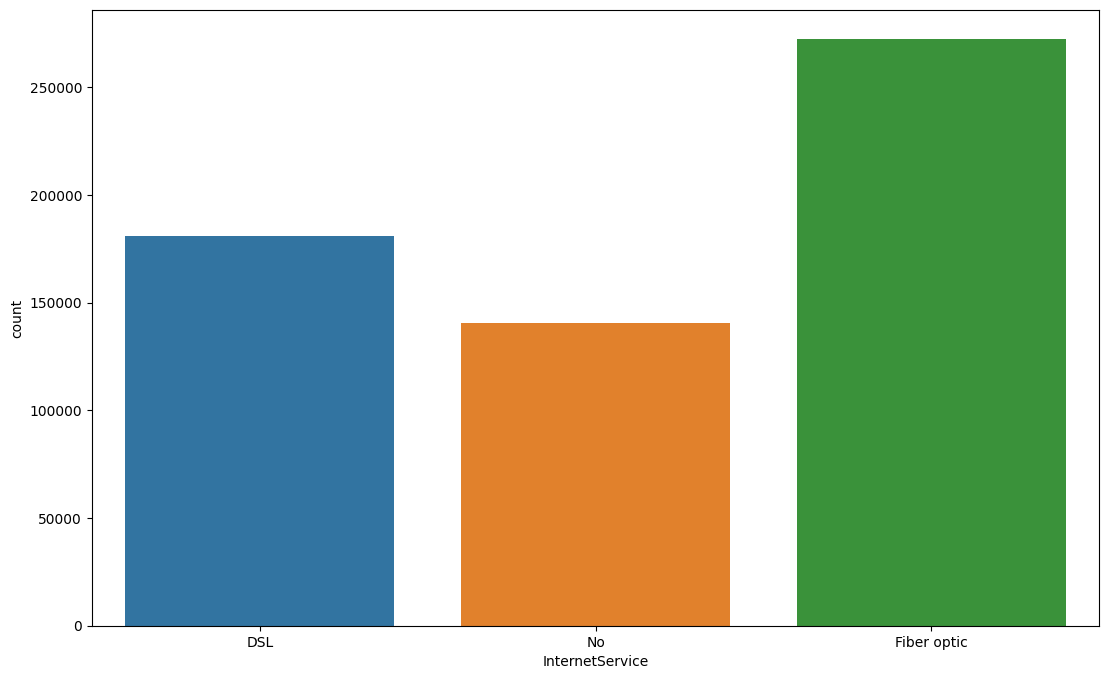

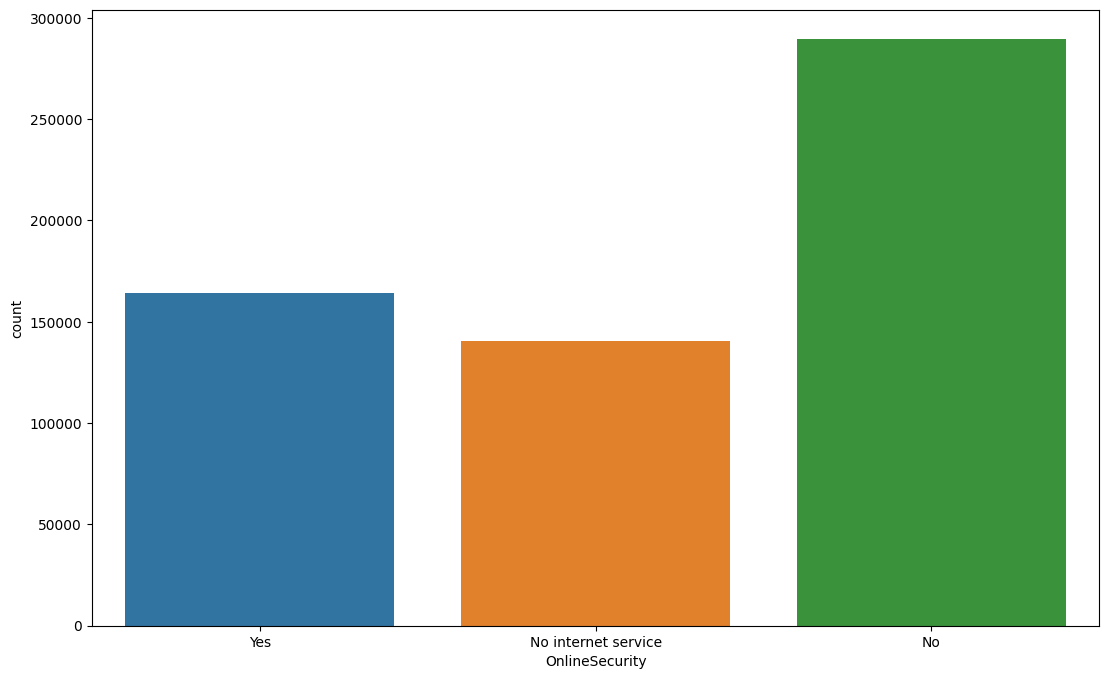

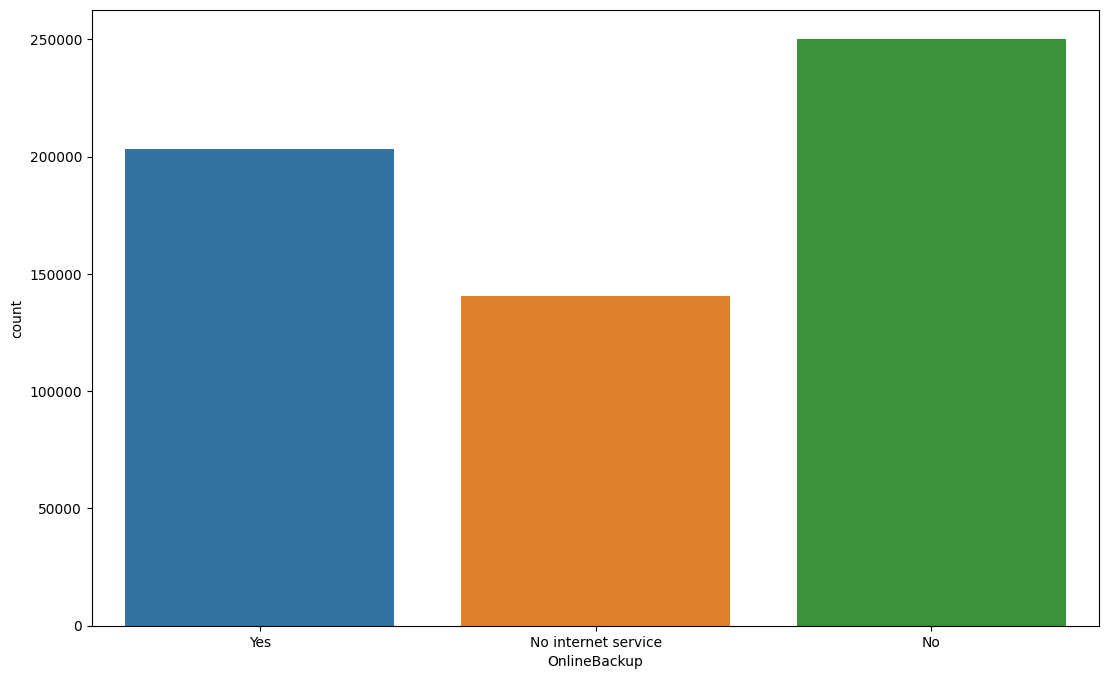

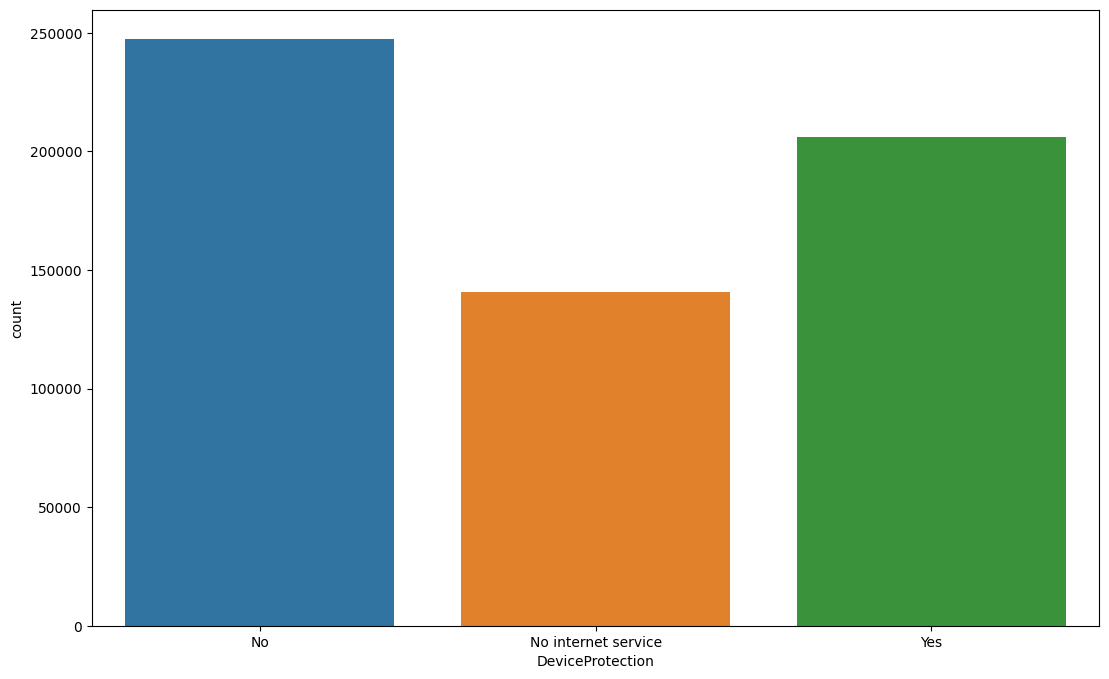

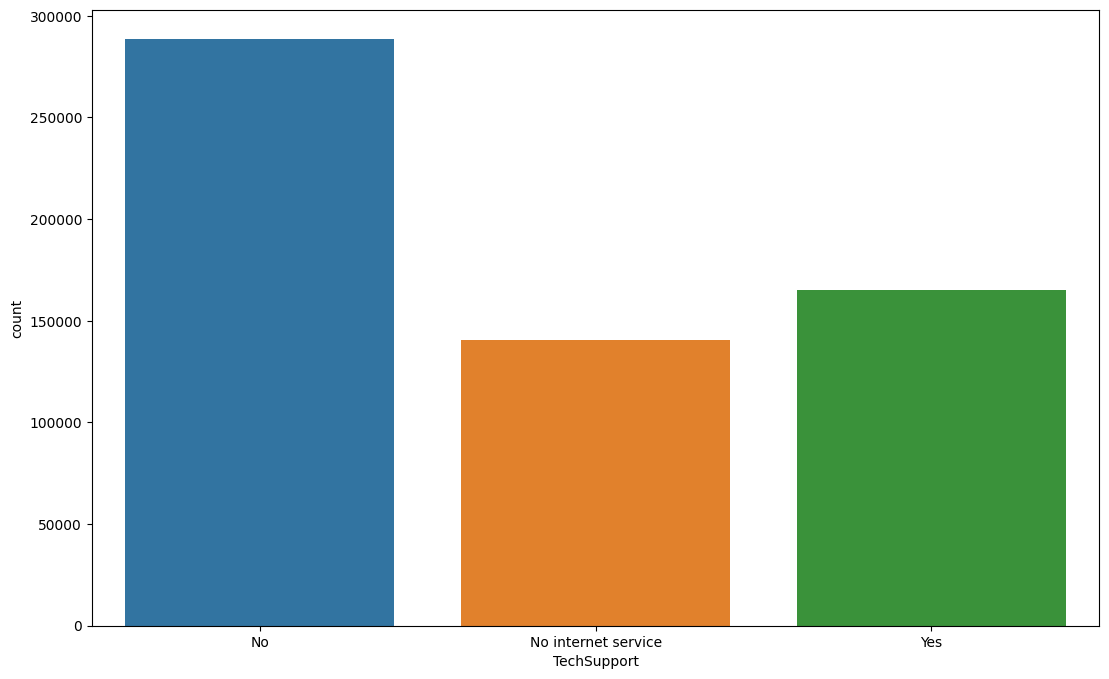

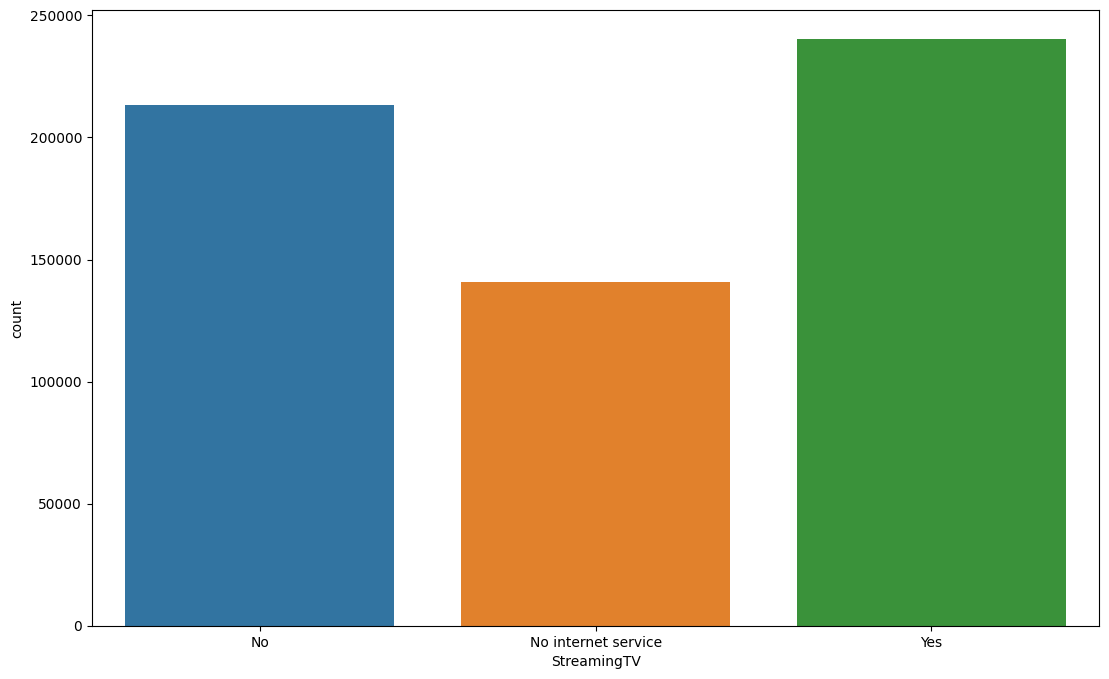

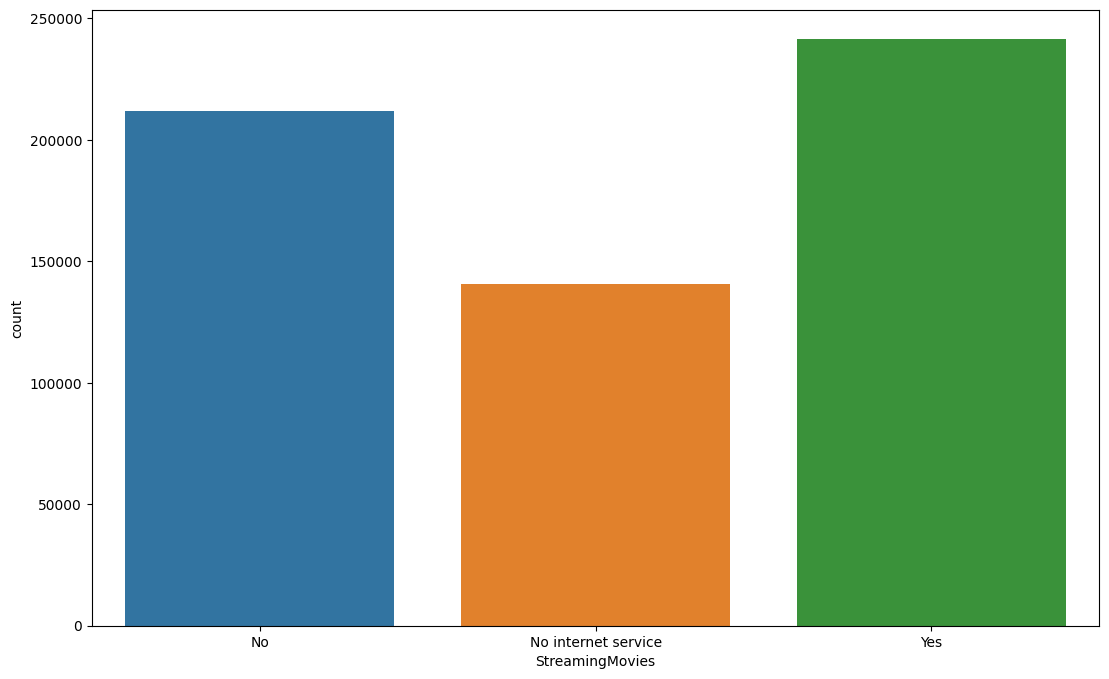

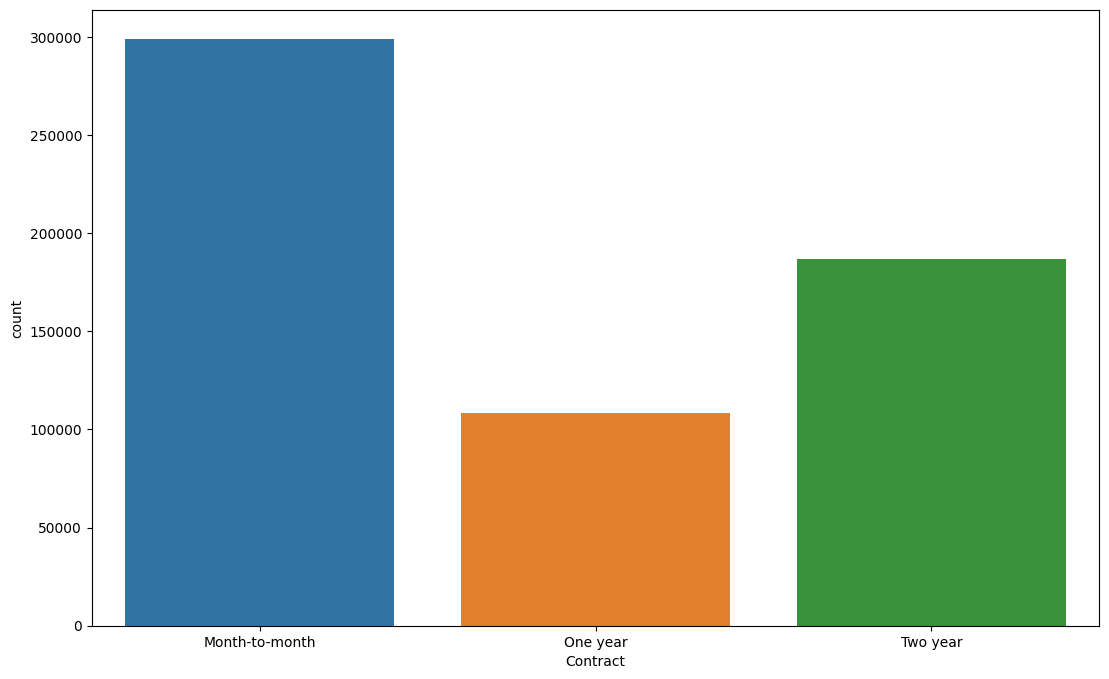

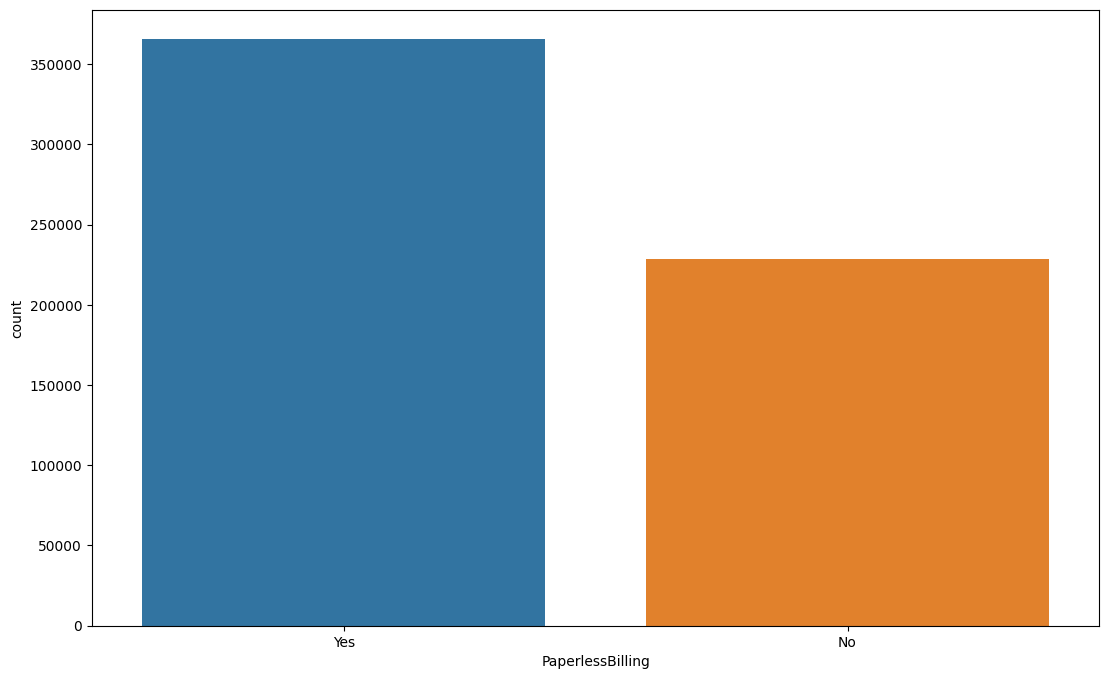

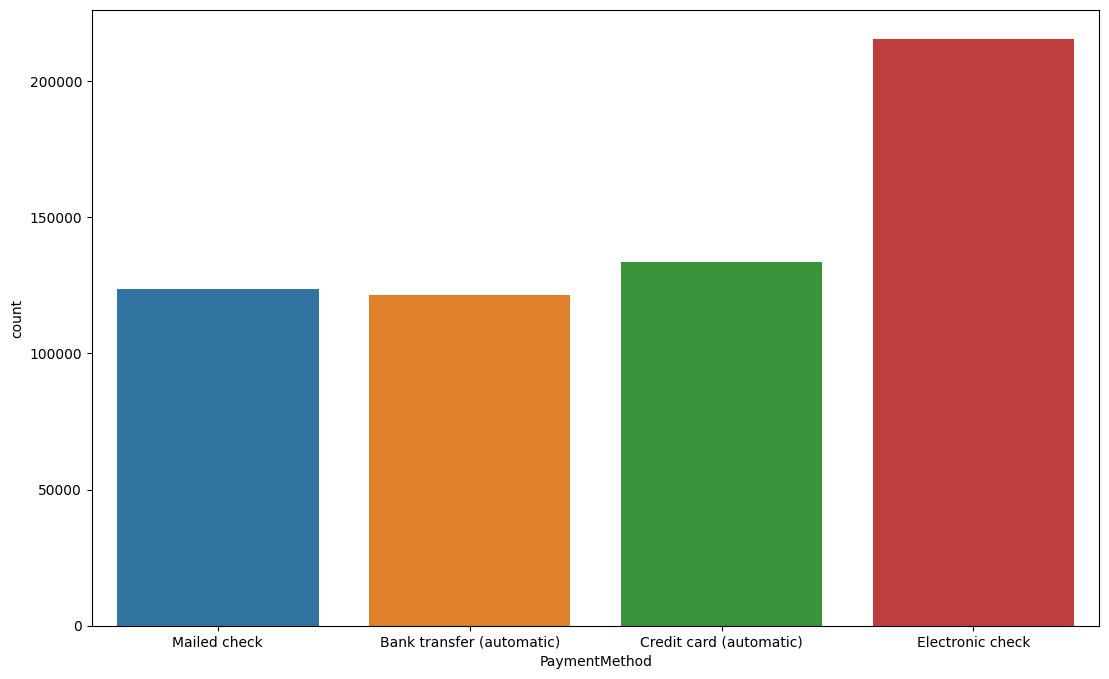

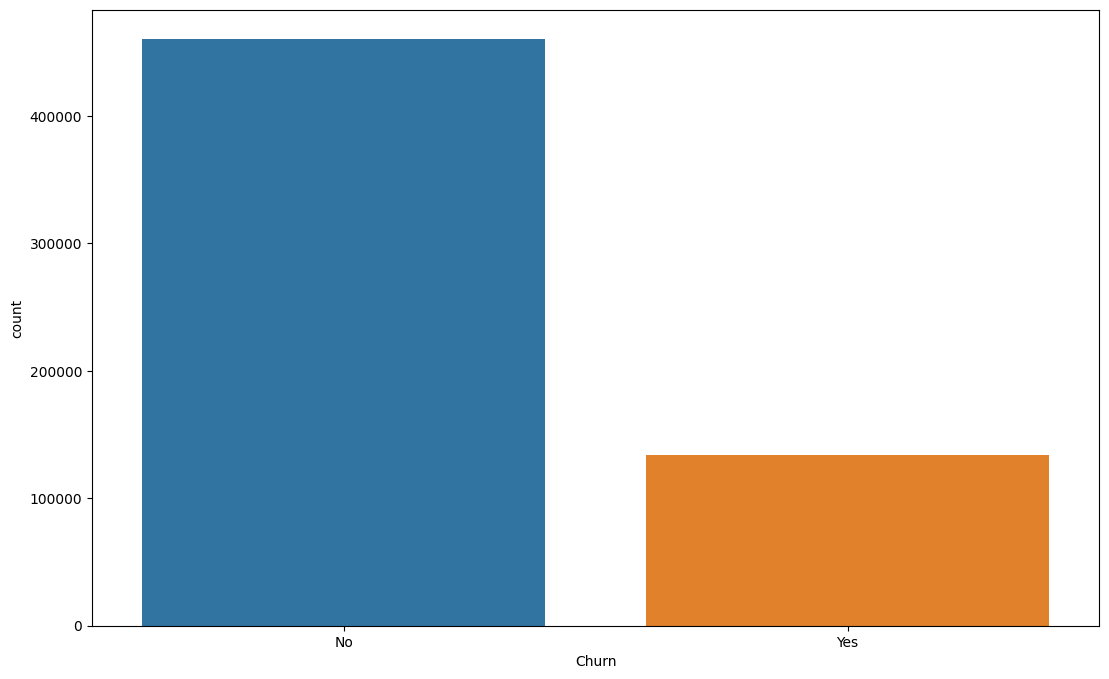

In [15]:
# Checking distribution of categories 
for col in categorical_columns:
    plt.figure(figsize=(13,8))
    sns.countplot(data=pd_df, x=col, hue=col)

In [16]:
# sns.pairplot(data=pd_df, vars=numeric_columns, hue='Churn')

In [17]:
pd_df.Churn.value_counts(normalize=True)

Churn
No     0.774792
Yes    0.225208
Name: proportion, dtype: float64

In [18]:
numeric_df = train.select(numeric_columns)
numeric_df.show(1)

+-------------+------+--------------+------------+
|SeniorCitizen|tenure|MonthlyCharges|TotalCharges|
+-------------+------+--------------+------------+
|            0|     9|         61.25|      605.85|
+-------------+------+--------------+------------+
only showing top 1 row


In [19]:
# Removing encoded column:seniorcitizen from numerical columns
cont_num = [col for col in numeric_columns if col != 'SeniorCitizen']


assembler = VectorAssembler(inputCols=cont_num, outputCol="features")
df_vec = assembler.transform(numeric_df).select("features")


corr_matrix = Correlation.corr(df_vec, "features", method="pearson")
matrix = corr_matrix.collect()[0]["pearson(features)"].toArray()

# Converting to pandas_df for readability
corr_df = pd.DataFrame(matrix, index=cont_num, columns=cont_num)
print(corr_df)

                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.124043      0.769703
MonthlyCharges  0.124043        1.000000      0.634237
TotalCharges    0.769703        0.634237      1.000000


In [20]:
numeric_columns = corr_df.columns.tolist()
numeric_df = train.select(numeric_columns)
categorical_columns.append('SeniorCitizen')
categorical_columns


['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn',
 'SeniorCitizen']

In [21]:
categorical_columns.pop(-2)
cat_df = train.select(categorical_columns)
cat_df.show(1, vertical=True)

-RECORD 0--------------------------
 gender           | Male           
 Partner          | No             
 Dependents       | No             
 PhoneService     | Yes            
 MultipleLines    | Yes            
 InternetService  | DSL            
 OnlineSecurity   | Yes            
 OnlineBackup     | Yes            
 DeviceProtection | No             
 TechSupport      | No             
 StreamingTV      | No             
 StreamingMovies  | No             
 Contract         | Month-to-month 
 PaperlessBilling | Yes            
 PaymentMethod    | Mailed check   
 SeniorCitizen    | 0              
only showing top 1 row


In [22]:
categorical_columns
def cramers_v(cat_df, col_a, col_b):
    crosstab = cat_df.stat.crosstab(col_a, col_b)
    
    crosstab_pd = crosstab.toPandas()
    crosstab_pd = crosstab_pd.set_index(crosstab_pd.columns[0])
    
    chi2, _, _, _ = chi2_contingency(crosstab_pd.values)
    
    n = crosstab_pd.values.sum()
    min_dim = min(crosstab_pd.shape) - 1
    v = np.sqrt(chi2 / (n * min_dim))
    
    return v

In [23]:
results = []

for i in range(len(categorical_columns)):
    for j in range(i + 1, len(categorical_columns)):
        col_a = categorical_columns[i]
        col_b = categorical_columns[j]
        v = cramers_v(train, col_a, col_b)
        results.append((col_a, col_b, round(v, 4)))


In [24]:
cramers_pd = pd.DataFrame(results, columns=['column 1', 'column 2', 'cramers v'])
cramers_pd[cramers_pd['cramers v']>.8]

,column 1,column 2,cramers v
42,PhoneService,MultipleLines,1.0000
105,StreamingTV,StreamingMovies,0.8113


In [25]:
# Removing correlated features
cat_df = cat_df.drop('PhoneService', 'StreamingTV')
cat_df.show(1, vertical=True)

-RECORD 0--------------------------
 gender           | Male           
 Partner          | No             
 Dependents       | No             
 MultipleLines    | Yes            
 InternetService  | DSL            
 OnlineSecurity   | Yes            
 OnlineBackup     | Yes            
 DeviceProtection | No             
 TechSupport      | No             
 StreamingMovies  | No             
 Contract         | Month-to-month 
 PaperlessBilling | Yes            
 PaymentMethod    | Mailed check   
 SeniorCitizen    | 0              
only showing top 1 row


In [26]:
cat_df.show(1)

+------+-------+----------+-------------+---------------+--------------+------------+----------------+-----------+---------------+--------------+----------------+-------------+-------------+
|gender|Partner|Dependents|MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingMovies|      Contract|PaperlessBilling|PaymentMethod|SeniorCitizen|
+------+-------+----------+-------------+---------------+--------------+------------+----------------+-----------+---------------+--------------+----------------+-------------+-------------+
|  Male|     No|        No|          Yes|            DSL|           Yes|         Yes|              No|         No|             No|Month-to-month|             Yes| Mailed check|            0|
+------+-------+----------+-------------+---------------+--------------+------------+----------------+-----------+---------------+--------------+----------------+-------------+-------------+
only showing top 1 row


In [27]:
categorical_columns, numeric_columns

(['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod',
  'SeniorCitizen'],
 ['tenure', 'MonthlyCharges', 'TotalCharges'])

In [28]:
# Fitting  model